In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# Temporary transform
temp_transform = transforms.ToTensor()

# Load training data (without normalization)
temp_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=temp_transform)
temp_loader  = DataLoader(temp_dataset, batch_size=1000, shuffle=False)

# Compute mean and std
mean = 0.0
std = 0.0
num_batches = 0

for images, _ in temp_loader:
    batch_samples = images.size(0)
    images = images.view(batch_samples, -1)
    mean += images.mean(1).sum()
    std += images.std(1).sum()
    num_batches += batch_samples

mean /= num_batches
std /= num_batches

print(f"Calculated Mean: {mean:.4f}, Std: {std:.4f}")

# Apply normalization using computed values
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((mean,), (std,))
])

# Reload datasets with proper normalization
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)

Using device: cuda


100%|██████████| 9.91M/9.91M [00:01<00:00, 6.09MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 161kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.17MB/s]


Calculated Mean: 0.1307, Std: 0.3015


In [3]:
class CNN_Dropout(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)

In [4]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
    return running_loss / len(loader.dataset)

In [5]:
model = CNN_Dropout(0).to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
for epoch in range(5):
    train_epoch(model, train_loader, opt, criterion, device)

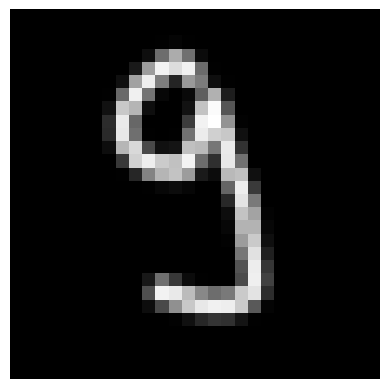

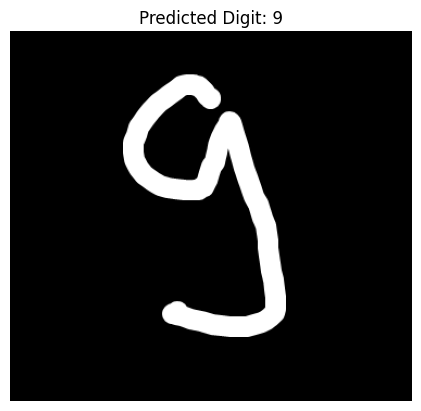

Predicted Digit: 9


In [6]:
img = Image.open("/kaggle/input/number/nine (2).png").convert("L")
img = ImageOps.invert(img)
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


img_tensor = transform(img).squeeze(0)
plt.imshow(img_tensor, cmap='gray')
plt.axis('off')
plt.show()

img_tensor = transform(img).unsqueeze(0).to(device)
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    pred = torch.argmax(output, dim=1).item()

plt.imshow(img, cmap='gray')
plt.title(f"Predicted Digit: {pred}")
plt.axis('off')
plt.show()

print("Predicted Digit:", pred)